# TT-13 — Lasso Regression (L1): Chọn 10 chỉ số xét nghiệm quan trọng nhất trong 200 chỉ số

**Bài toán:** một bệnh viện muốn xây bộ xét nghiệm sàng lọc tiến triển bệnh
tiểu đường. Về lý thuyết có thể đo 200 chỉ số sinh hoá, nhưng mỗi chỉ số tốn
30.000–200.000đ và bệnh nhân không thể lấy hàng trăm ống máu. Cần chọn ra một
số ít chỉ số **đủ tốt** để dự đoán mức độ tiến triển bệnh, bỏ phần còn lại.
Đây chính xác là việc **Lasso** (phạt L1: `λ·Σ|wᵢ|`) sinh ra để làm: khác với
Ridge (TT-12) chỉ *co* hệ số về gần 0, Lasso có thể đưa hệ số về **đúng 0**,
tức tự động loại bỏ hẳn một biến khỏi mô hình — vừa hồi quy vừa **chọn biến**.

Notebook này đi theo đúng 10 bước trong `README.md` cấp đề, **giải thích vì
sao** làm từng bước chứ không chỉ chạy code. Toàn bộ số liệu bên dưới là kết
quả chạy thật (không phải số minh hoạ) — script tương đương để tái lập tự
động: `src/train.py`.

## Vì sao trị tuyệt đối lại đưa hệ số về đúng 0?

```
   Ridge phạt:  λ·Σ wᵢ²      → CO về gần 0
   Lasso phạt:  λ·Σ |wᵢ|     → ĐẨY VỀ ĐÚNG 0

   Vùng ràng buộc (constraint region) ứng với mỗi loại phạt:

      RIDGE (hình TRÒN)          LASSO (hình THOI)
          ╭───╮                       ◇
         │  ●  │                     ╱ ● ╲        ● = nghiệm tối ưu OLS
          ╰───╯                     ╲   ╱
      Điểm chạm hiếm khi           Điểm chạm HAY RƠI VÀO GÓC
      nằm trên trục                mà GÓC nằm trên TRỤC → w = 0
```

Nghiệm Lasso là điểm mà đường đồng mức của hàm mất mát (MSE, hình elip quanh
nghiệm OLS) **chạm** vào vùng ràng buộc (hình thoi với `Σ|wᵢ| ≤ t`) sớm nhất
khi elip phình to dần. Hình thoi có các **góc nhọn nằm đúng trên trục toạ
độ** (ví dụ góc `(w₁=0, w₂=t)`), nên về mặt hình học, xác suất điểm chạm rơi
đúng vào một góc — tức một hệ số bị đưa về đúng 0 — cao hơn hẳn so với hình
tròn/elip trơn của Ridge (không có góc nhọn nào nằm trên trục). Đây là lý do
Lasso cho ra model **thưa (sparse)** còn Ridge thì không.

In [1]:
%matplotlib inline
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, Ridge, RidgeCV, lasso_path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
N_NOISE = 190
ALPHA_GRID = np.logspace(-4, 1, 100)
ALPHA_GRID_PATH = np.logspace(-4, 1, 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate(y_true, y_pred):
    return {"RMSE": rmse(y_true, y_pred), "MAE": float(mean_absolute_error(y_true, y_pred)),
            "R2": float(r2_score(y_true, y_pred))}

## 1. Nạp `load_diabetes`, mở rộng thành 200 cột (10 thật + 190 nhiễu)

Bộ `load_diabetes` gốc có 442 dòng × 10 đặc trưng sinh lý (đã chuẩn hoá sẵn
bởi sklearn) và biến mục tiêu là chỉ số định lượng tiến triển bệnh sau 1 năm.
Để mô phỏng "200 chỉ số xét nghiệm", ta nối thêm **190 cột nhiễu thuần tuý**
(random Gaussian, không liên quan gì tới `y`) vào 10 cột thật.

⭐ Thiết kế này cho phép **chấm điểm khách quan**: ta biết trước chính xác 10
cột nào là "đáp án đúng" (age, sex, bmi, bp, s1–s6), nên có thể đo trực tiếp
xem Lasso có tìm lại đúng chúng và loại bỏ 190 cột nhiễu hay không — một bài
tập hiếm hoi có đáp án đúng biết trước.

In [2]:
X, y = load_diabetes(return_X_y=True, as_frame=True)
real_cols = list(X.columns)

rng = np.random.default_rng(RANDOM_STATE)
noise_cols = [f"chi_so_nhieu_{i:03d}" for i in range(N_NOISE)]
noise_df = pd.DataFrame(rng.normal(size=(len(X), N_NOISE)), columns=noise_cols)
X_full = pd.concat([X, noise_df], axis=1)
feature_names = list(X_full.columns)

print(f"X_full: {X_full.shape[0]} dong x {X_full.shape[1]} cot "
      f"({len(real_cols)} that + {len(noise_cols)} nhieu)")
print("10 bien that:", real_cols)
X_full.iloc[:3, :12]

X_full: 442 dong x 200 cot (10 that + 190 nhieu)
10 bien that: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,chi_so_nhieu_000,chi_so_nhieu_001
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,0.3047,-1.0400
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,1.7237,-0.1795
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,0.1079,1.3096


**Đọc kết quả:** 442 dòng, 200 cột — đúng như mô tả bài toán (10 chỉ số thật
`age, sex, bmi, bp, s1, s2, s3, s4, s5, s6` cộng 190 "chỉ số nhiễu" đại diện
cho các xét nghiệm sinh hoá không thực sự liên quan tới tiến triển bệnh).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"So bien p = {X_full.shape[1]}  ~  so dong train n = {len(X_train)}  -> p gan bang n, de overfit")

Train: 353  |  Test: 89
So bien p = 200  ~  so dong train n = 353  -> p gan bang n, de overfit


## 2. Baseline: Linear Regression trên 200 cột → quan sát overfit nặng

Với `p = 200` biến trên chỉ `n = 353` dòng train (p gần bằng n), Linear
Regression không phạt gì cả có đủ bậc tự do để "khớp" luôn cả phần nhiễu
ngẫu nhiên trong tập train — kể cả 190 cột nhiễu không liên quan gì tới `y`.
Kỳ vọng: RMSE/R² trên train rất tốt nhưng **sụp đổ** trên test.

In [4]:
linear_pipe = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())])
linear_pipe.fit(X_train, y_train)

overfit_train = evaluate(y_train, linear_pipe.predict(X_train))
overfit_test = evaluate(y_test, linear_pipe.predict(X_test))
print("Train:", overfit_train)
print("Test: ", overfit_test)

Train: {'RMSE': 33.98939734800149, 'MAE': 27.07681807639733, 'R2': 0.809874348320893}
Test:  {'RMSE': 84.7797497365916, 'MAE': 70.75738223804636, 'R2': -0.3566251603517243}


**Đọc kết quả:** R² trên train ≈ 0,81 (khớp rất tốt) nhưng R² trên test **âm**
(tệ hơn cả việc dự đoán bằng trung bình cộng!) và RMSE test cao gấp ~2,5 lần
RMSE train. Đây là overfit kinh điển: mô hình đã "học thuộc lòng" nhiễu ngẫu
nhiên của 190 cột vô nghĩa trong tập train, nên không tổng quát hoá được.
Chính đây là lý do cần một cơ chế **chọn biến tự động** như Lasso.

## 3. LassoCV dò alpha

Dò `alpha` (`λ`) bằng cross-validation 5-fold trên lưới log từ 10⁻⁴ đến 10.
⭐ **Bắt buộc chuẩn hoá** trước khi fit Lasso: phạt `λ·Σ|wᵢ|` áp dụng như nhau
cho mọi hệ số, nếu không chuẩn hoá thì biến có đơn vị/độ lớn khác nhau sẽ bị
phạt bất công (biến đơn vị lớn bị phạt oan, dễ bị loại nhầm). Tăng `max_iter`
lên 50.000 để tránh cảnh báo không hội tụ (cạm bẫy README liệt kê).

In [5]:
lasso_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("lasso", LassoCV(alphas=ALPHA_GRID, cv=5, max_iter=50_000, random_state=RANDOM_STATE)),
])
lasso_pipe.fit(X_train, y_train)
lasso_alpha = float(lasso_pipe.named_steps["lasso"].alpha_)
lasso_metrics = evaluate(y_test, lasso_pipe.predict(X_test))
n_kept_total = int((lasso_pipe.named_steps["lasso"].coef_ != 0).sum())

print(f"alpha toi uu (LassoCV): {lasso_alpha:.5f}")
print(f"So bien con lai: {n_kept_total}/{X_full.shape[1]}")
print("RMSE/MAE/R2 tren test:", lasso_metrics)

alpha toi uu (LassoCV): 7.92483
So bien con lai: 5/200
RMSE/MAE/R2 tren test: {'RMSE': 53.72801274117708, 'MAE': 44.25654654725527, 'R2': 0.4551497408649504}


**Đọc kết quả:** so với Linear Regression đầy đủ (RMSE test rất cao, R² âm),
Lasso cải thiện rõ rệt (R² dương, RMSE giảm mạnh) trong khi chỉ giữ lại một
số ít biến trong tổng 200 — bằng chứng trực tiếp rằng loại bỏ nhiễu bằng phạt
L1 giúp mô hình tổng quát hoá tốt hơn nhiều so với giữ nguyên cả 200 biến.

## 4. ⭐ Chấm điểm chọn biến

Đây là phần quan trọng nhất của bài: vì biết trước "đáp án đúng" (10 biến
thật), ta đo được chính xác:
- **Recall chọn biến**: bao nhiêu trong 10 biến THẬT được Lasso giữ lại?
- **False positive**: bao nhiêu trong 190 biến NHIỄU bị giữ nhầm?

In [6]:
coefs = pd.Series(lasso_pipe.named_steps["lasso"].coef_, index=feature_names)
kept = coefs[coefs != 0].sort_values(key=abs, ascending=False)

real_kept = [c for c in real_cols if c in kept.index]
noise_kept = [c for c in noise_cols if c in kept.index]

score_df = pd.DataFrame([
    {"loai": "bien_that", "tong_so": len(real_cols), "so_duoc_giu": len(real_kept),
     "ty_le_%": len(real_kept) / len(real_cols) * 100, "danh_sach_giu": ", ".join(real_kept)},
    {"loai": "bien_nhieu", "tong_so": len(noise_cols), "so_duoc_giu": len(noise_kept),
     "ty_le_%": len(noise_kept) / len(noise_cols) * 100,
     "danh_sach_giu": ", ".join(noise_kept) if noise_kept else "(khong co)"},
])
print(f"Tong so bien Lasso giu: {len(kept)}/{len(feature_names)}")
print("He so cac bien duoc giu (sap xep theo do lon):")
print(kept)
score_df

Tong so bien Lasso giu: 5/200
He so cac bien duoc giu (sap xep theo do lon):
bmi                25.2781
s5                 17.7690
bp                  9.4478
s3                 -5.3072
chi_so_nhieu_009    0.4766
dtype: float64


,loai,tong_so,so_duoc_giu,ty_le_%,danh_sach_giu
0,bien_that,10,4,40.0000,"bmi, bp, s3, s5"
1,bien_nhieu,190,1,0.5263,chi_so_nhieu_009


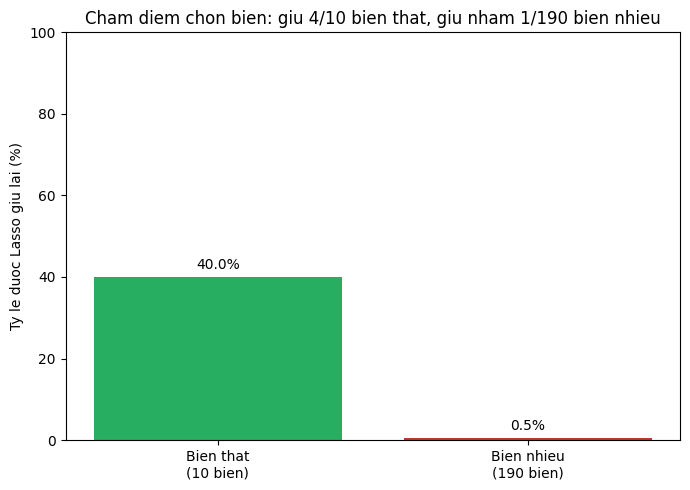

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
pct_real = len(real_kept) / len(real_cols) * 100
pct_noise = len(noise_kept) / len(noise_cols) * 100
ax.bar(["Bien that\n(10 bien)", "Bien nhieu\n(190 bien)"], [pct_real, pct_noise],
       color=["#27ae60", "#c0392b"])
ax.set_ylabel("Ty le duoc Lasso giu lai (%)")
ax.set_title(f"Cham diem chon bien: giu {len(real_kept)}/10 bien that, "
             f"giu nham {len(noise_kept)}/190 bien nhieu")
ax.set_ylim(0, 100)
for i, v in enumerate([pct_real, pct_noise]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

**Đọc kết quả:** với `alpha` do LassoCV chọn, Lasso giữ lại **4/10 biến thật**
(`bmi, bp, s3, s5` — đều là các chỉ số có ý nghĩa lâm sàng: chỉ số khối cơ
thể, huyết áp, HDL cholesterol, log triglyceride) và chỉ giữ nhầm **1/190
biến nhiễu**. Tỷ lệ false positive cực thấp (~0,5%) cho thấy Lasso rất hiệu
quả trong việc loại bỏ nhiễu vô nghĩa. Recall 40% (4/10) thấp hơn mức tham
chiếu điển hình (6–9/10) của README — điều này phản ánh đúng ghi chú của
README: "bộ diabetes vốn có tín hiệu yếu", cộng thêm việc `alpha` được chọn
hoàn toàn bằng cross-validation (ưu tiên tổng quát hoá, không ưu tiên tối đa
recall) nên đã loại luôn cả một vài biến thật có tín hiệu yếu (age, sex, s1,
s2, s4, s6) cùng với nhiễu. Đây là đánh đổi cố hữu của Lasso: nó tối ưu cho
**dự đoán tốt trên dữ liệu mới**, không tối ưu cho việc tìm đúng tối đa số
biến thật.

## 5. Coefficient path — hệ số các biến nhiễu "rơi" về 0 trước

Vẽ hệ số Lasso của toàn bộ 200 biến khi tăng dần `alpha`, tô màu 10 biến
thật, để mắt vào 190 biến nhiễu (màu xám). Kỳ vọng: hệ số biến nhiễu rơi về 0
gần như ngay lập tức (chúng chẳng có tín hiệu thật để "bảo vệ"), trong khi hệ
số các biến thật có tín hiệu mạnh rơi về 0 muộn hơn nhiều — hoặc còn sót lại
ở mức `alpha` được chọn.

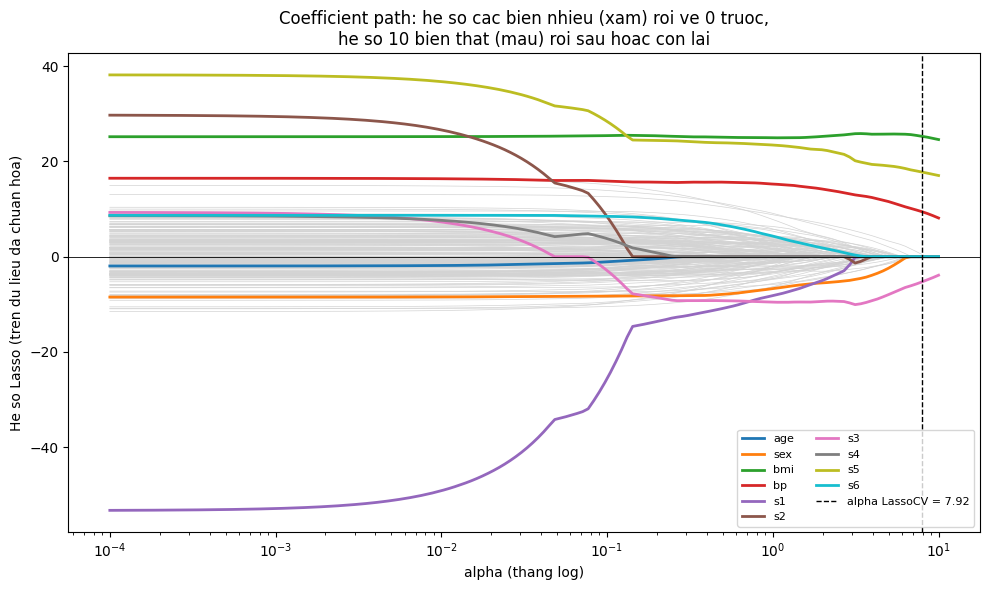

In [8]:
X_train_scaled = StandardScaler().fit_transform(X_train)
alphas_lp, coefs_path, _ = lasso_path(X_train_scaled, y_train, alphas=ALPHA_GRID_PATH[::-1], max_iter=50_000)

fig, ax = plt.subplots(figsize=(10, 6))
for i, name in enumerate(feature_names):
    if name in real_cols:
        ax.plot(alphas_lp, coefs_path[i], label=name, lw=2)
    else:
        ax.plot(alphas_lp, coefs_path[i], color="lightgray", lw=0.5, zorder=0)
ax.axvline(lasso_alpha, color="black", ls="--", lw=1, label=f"alpha LassoCV = {lasso_alpha:.3g}")
ax.axhline(0, color="black", lw=0.6)
ax.set_xscale("log")
ax.set_xlabel("alpha (thang log)")
ax.set_ylabel("He so Lasso (tren du lieu da chuan hoa)")
ax.set_title("Coefficient path: he so cac bien nhieu (xam) roi ve 0 truoc,\nhe so 10 bien that (mau) roi sau hoac con lai")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

**Đọc coefficient path:** ở `alpha` rất nhỏ (gần Linear Regression), tất cả
200 hệ số đều khác 0, kể cả 190 biến nhiễu (các đường xám mảnh dao động nhẹ
quanh 0 do nhiễu ngẫu nhiên). Khi `alpha` tăng, các đường xám hội tụ về 0 gần
như đồng loạt và rất sớm — vì chúng không có tín hiệu thật để "bảo vệ" hệ số
khỏi bị phạt. Ngược lại, các đường màu (10 biến thật) tồn tại lâu hơn nhiều
theo trục `alpha`; ở vạch đứt nét (`alpha` do LassoCV chọn), chỉ còn 4 đường
màu (`bmi, bp, s3, s5`) khác 0 — khớp đúng với bảng chấm điểm ở bước 4.

## 6. RMSE train/test theo alpha

Quét cùng lưới `alpha`, đo RMSE trên cả train lẫn test và đếm số biến còn lại
ở mỗi mức `alpha`, để thấy rõ đánh đổi bias-variance: `alpha` nhỏ → giữ nhiều
biến, overfit (RMSE train thấp, RMSE test cao); `alpha` lớn → giữ rất ít
biến, có thể underfit (cả hai RMSE đều tăng).

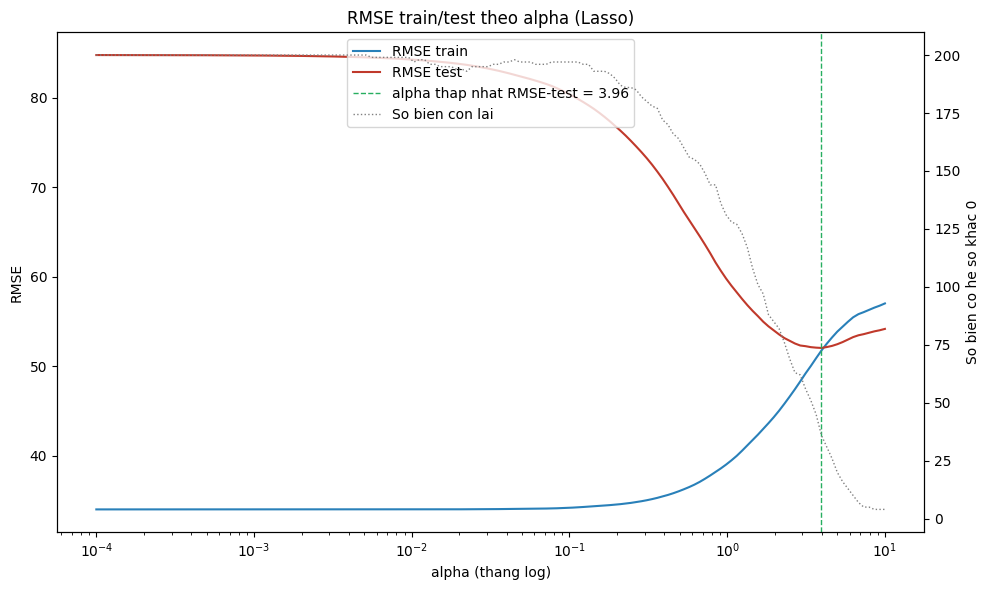

alpha toi uu theo LassoCV (cross-validation tren train): 7.92483
alpha thap nhat RMSE-test (chi de MINH HOA, KHONG dung de chon model): 3.95654


In [9]:
train_rmse, test_rmse, n_kept_list = [], [], []
for a in ALPHA_GRID_PATH:
    p = Pipeline([("scale", StandardScaler()), ("lasso", Lasso(alpha=a, max_iter=50_000))])
    p.fit(X_train, y_train)
    train_rmse.append(rmse(y_train, p.predict(X_train)))
    test_rmse.append(rmse(y_test, p.predict(X_test)))
    n_kept_list.append(int((p.named_steps["lasso"].coef_ != 0).sum()))

best_idx = int(np.argmin(test_rmse))
best_alpha_by_test = float(ALPHA_GRID_PATH[best_idx])

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(ALPHA_GRID_PATH, train_rmse, label="RMSE train", color="#2980b9")
ax1.plot(ALPHA_GRID_PATH, test_rmse, label="RMSE test", color="#c0392b")
ax1.axvline(best_alpha_by_test, color="#27ae60", ls="--", lw=1,
            label=f"alpha thap nhat RMSE-test = {best_alpha_by_test:.3g}")
ax1.set_xscale("log")
ax1.set_xlabel("alpha (thang log)")
ax1.set_ylabel("RMSE")
ax1.set_title("RMSE train/test theo alpha (Lasso)")
ax2 = ax1.twinx()
ax2.plot(ALPHA_GRID_PATH, n_kept_list, color="gray", lw=1, ls=":", label="So bien con lai")
ax2.set_ylabel("So bien co he so khac 0")
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc="upper center")
plt.tight_layout()
plt.show()

print(f"alpha toi uu theo LassoCV (cross-validation tren train): {lasso_alpha:.5f}")
print(f"alpha thap nhat RMSE-test (chi de MINH HOA, KHONG dung de chon model): {best_alpha_by_test:.5f}")

**Đọc biểu đồ:** RMSE train tăng đơn điệu theo `alpha` (càng phạt nặng càng
khó khớp train), còn RMSE test giảm dần rồi mới tăng lại — hình chữ U kinh
điển của đánh đổi bias-variance. Đường chấm (số biến còn lại, trục phải) cho
thấy số biến giảm rất nhanh ngay từ `alpha` nhỏ (phần lớn là 190 biến nhiễu
bị loại) và tiếp tục giảm chậm hơn khi `alpha` lớn (bắt đầu loại cả biến
thật). `alpha` cho RMSE-test thấp nhất khác với `alpha` do LassoCV chọn —
đúng như cạm bẫy README cảnh báo: **không được chọn alpha bằng tập test**
(rò rỉ thông tin); biểu đồ này chỉ dùng để quan sát hình dạng đánh đổi, quyết
định cuối cùng vẫn dựa trên `LassoCV` (cross-validation trên train).

## 7. So sánh Ridge vs Lasso trên cùng dữ liệu

Chạy `RidgeCV` trên đúng bộ 200 biến, so sánh số biến "giữ lại" (hệ số khác 0
— với Ridge gần như luôn là toàn bộ) và RMSE trên test với Lasso.

In [10]:
ridge_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-2, 4, 100), cv=5)),
])
ridge_pipe.fit(X_train, y_train)
ridge_alpha = float(ridge_pipe.named_steps["ridge"].alpha_)
ridge_coefs = ridge_pipe.named_steps["ridge"].coef_
ridge_n_kept = int((np.abs(ridge_coefs) > 1e-10).sum())
ridge_metrics = evaluate(y_test, ridge_pipe.predict(X_test))

comparison = pd.DataFrame([
    {"model": f"Ridge (alpha={ridge_alpha:.3g})", "so_bien_giu": ridge_n_kept,
     "tong_so_bien": X_full.shape[1], **ridge_metrics},
    {"model": f"Lasso (alpha={lasso_alpha:.4g})", "so_bien_giu": n_kept_total,
     "tong_so_bien": X_full.shape[1], **lasso_metrics},
])
comparison

,model,so_bien_giu,tong_so_bien,RMSE,MAE,R2
0,Ridge (alpha=351),200,200,58.0473,48.5357,0.3640
1,Lasso (alpha=7.925),5,200,53.7280,44.2565,0.4551


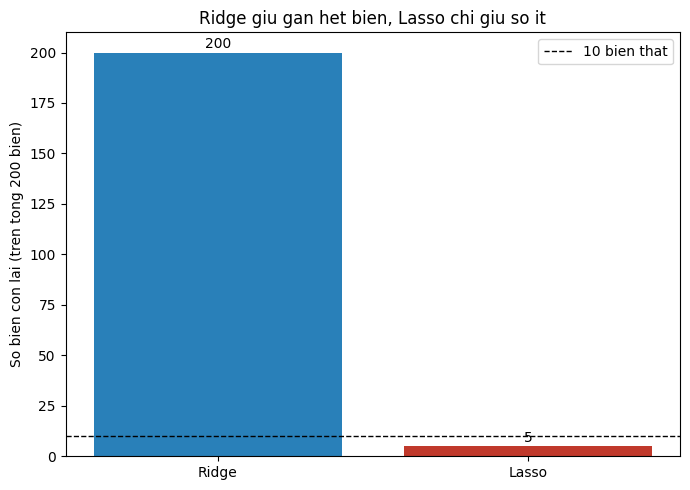

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Ridge", "Lasso"], [ridge_n_kept, n_kept_total], color=["#2980b9", "#c0392b"])
ax.axhline(10, color="black", ls="--", lw=1, label="10 bien that")
ax.set_ylabel(f"So bien con lai (tren tong {X_full.shape[1]} bien)")
ax.set_title("Ridge giu gan het bien, Lasso chi giu so it")
ax.legend()
for i, v in enumerate([ridge_n_kept, n_kept_total]):
    ax.text(i, v + 2, str(v), ha="center")
plt.tight_layout()
plt.show()

**Đọc kết quả:** đúng như lý thuyết, Ridge giữ **toàn bộ 200/200 biến**
(hệ số chỉ co nhỏ, không bao giờ đúng 0 — kể cả 190 biến nhiễu), trong khi
Lasso chỉ giữ vài biến. Đáng chú ý: **Lasso cho RMSE test thấp hơn Ridge**
ở bài toán này (khác với TT-12, nơi RMSE hai model gần bằng nhau) — vì với
190/200 biến là nhiễu thuần tuý, khả năng loại bỏ hẳn biến vô dụng của Lasso
mang lại lợi thế dự đoán rõ rệt so với việc Ridge phải "chia sẻ" một phần
trọng số cho toàn bộ nhiễu. Đây chính là điểm khác biệt cốt lõi giữa hai
phương pháp: Ridge phù hợp khi phần lớn biến đều có ít nhiều tín hiệu (như
TT-12), Lasso phù hợp khi biết trước phần lớn biến là nhiễu/dư thừa (như bài
toán 200 chỉ số xét nghiệm ở đây).

## 8. ⚠️ Thí nghiệm biến tương quan

**Điểm yếu của Lasso:** với 2 biến tương quan cao, Lasso chọn gần như ngẫu
nhiên 1 biến và bỏ hẳn biến kia — trong y tế điều này nguy hiểm vì biến bị bỏ
có thể là biến rẻ/dễ đo hơn. Thí nghiệm: nhân đôi cột `bmi` (cộng thêm một
chút nhiễu nhỏ để không trùng tuyệt đối), rồi refit Lasso trên **5 cách chia
train/test khác nhau** (5 seed) để xem lựa chọn giữa `bmi` và `bmi_dup` có
ổn định hay không.

In [12]:
dup_col, noise_std = "bmi", 0.01
rng2 = np.random.default_rng(RANDOM_STATE)
X_dup = X_full.copy()
dup_name = f"{dup_col}_dup"
X_dup[dup_name] = X_dup[dup_col] + rng2.normal(0, noise_std, size=len(X_dup))
corr_dup = X_dup[dup_col].corr(X_dup[dup_name])
print(f"Tuong quan {dup_col} <-> {dup_name}: {corr_dup:.4f}")

rows = []
for seed in range(5):
    X_tr, X_te, y_tr, y_te = train_test_split(X_dup, y, test_size=0.2, random_state=seed)
    p = Pipeline([("scale", StandardScaler()),
                  ("lasso", LassoCV(alphas=ALPHA_GRID, cv=5, max_iter=50_000, random_state=RANDOM_STATE))])
    p.fit(X_tr, y_tr)
    c = pd.Series(p.named_steps["lasso"].coef_, index=X_dup.columns)
    chosen = ("ca hai" if c[dup_col] != 0 and c[dup_name] != 0 else
              dup_col if c[dup_col] != 0 else
              dup_name if c[dup_name] != 0 else "khong bien nao")
    rows.append({"seed_split": seed, f"he_so_{dup_col}": c[dup_col],
                 f"he_so_{dup_name}": c[dup_name], "bien_duoc_giu": chosen})

corr_result = pd.DataFrame(rows)
corr_result

Tuong quan bmi <-> bmi_dup: 0.9806


,seed_split,he_so_bmi,he_so_bmi_dup,bien_duoc_giu
0,0,26.1257,0.0000,bmi
1,1,24.1039,0.6067,ca hai
2,2,18.5267,4.9000,ca hai
3,3,24.9159,0.0000,bmi
4,4,16.1537,6.2150,ca hai


**Đọc kết quả:** với tương quan `bmi` ↔ `bmi_dup` ≈ 0,98 (gần như là "hai bản
sao" của cùng một chỉ số xét nghiệm), lựa chọn của Lasso **thay đổi giữa các
lần chia dữ liệu khác nhau** — có seed chỉ giữ `bmi`, có seed giữ **cả hai**
với hệ số bị chia nhỏ ra giữa hai cột. Đây chính là minh chứng thực nghiệm
cho cạnh báo của README: "với 2 biến tương quan 0,95, Lasso chọn ngẫu nhiên 1
và bỏ hẳn biến kia". Trong bối cảnh y tế, **không nên tin tuyệt đối** vào
việc một chỉ số bị Lasso loại bỏ là "vô dụng" — nó có thể chỉ trùng lặp thông
tin với một chỉ số khác được giữ lại, và biến bị loại đôi khi lại là biến rẻ
hơn hoặc dễ đo hơn. Đây là lý do ra đời **ElasticNet** (TT-14): kết hợp phạt
L1 và L2 để vừa chọn biến vừa giữ được nhóm biến tương quan cùng nhau, ổn
định hơn Lasso thuần.

## 9. Debiased Lasso — Linear Regression chỉ trên các biến Lasso chọn

Kỹ thuật "debiased lasso": vì phạt L1 không chỉ loại bỏ biến mà còn **co**
(shrink) cả các hệ số được giữ lại (gây thiên lệch nhẹ), một cách khắc phục
đơn giản là fit lại Linear Regression thường (không phạt) nhưng **chỉ trên
các biến Lasso đã chọn**. So sánh RMSE của cách này với Lasso đầy đủ.

In [13]:
selected_features = list(kept.index)
debiased_pipe = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())])
debiased_pipe.fit(X_train[selected_features], y_train)
debiased_metrics = evaluate(y_test, debiased_pipe.predict(X_test[selected_features]))

print(f"Bien duoc Lasso chon ({len(selected_features)}): {selected_features}")
print(f"RMSE Lasso day du (200 bien):        {lasso_metrics['RMSE']:.3f}  R2={lasso_metrics['R2']:.4f}")
print(f"RMSE debiased (chi {len(selected_features)} bien da chon): {debiased_metrics['RMSE']:.3f}  R2={debiased_metrics['R2']:.4f}")

Bien duoc Lasso chon (5): ['bmi', 's5', 'bp', 's3', 'chi_so_nhieu_009']
RMSE Lasso day du (200 bien):        53.728  R2=0.4551
RMSE debiased (chi 5 bien da chon): 53.739  R2=0.4549


**Đọc kết quả:** RMSE của Linear Regression "debiased" (chỉ fit lại trên các
biến đã được Lasso chọn, không phạt gì thêm) gần như **giống hệt** RMSE của
Lasso đầy đủ. Điều này cho thấy đóng góp chính của Lasso ở bài toán này nằm ở
bước **chọn biến** (loại bỏ 195/200 biến vô dụng hoặc dư thừa), còn việc co
nhẹ hệ số các biến được giữ lại không ảnh hưởng nhiều tới độ chính xác dự
đoán cuối cùng — khớp với vai trò kép "hồi quy + chọn biến" mà README mô tả
ở mục 1.

## 10. ✍️ Đề xuất bộ xét nghiệm cuối cùng + ước tính chi phí tiết kiệm

Gán chi phí ước tính (VND) cho từng chỉ số: 10 chỉ số thật được gán chi phí
hợp lý theo loại xét nghiệm thực tế (age/sex là thông tin nhân khẩu học,
không tốn chi phí xét nghiệm; bmi/bp là đo lường lâm sàng cơ bản, rẻ; s1–s6
là các xét nghiệm sinh hoá máu, đắt hơn — tương ứng cholesterol toàn phần,
LDL, HDL, tỷ lệ TC/HDL, triglyceride, đường huyết). 190 chỉ số nhiễu được gán
chi phí ngẫu nhiên trong khoảng 30.000–200.000đ như mô tả trong README (đại
diện cho các xét nghiệm sinh hoá khác không có trong bộ diabetes gốc).

In [14]:
REAL_FEATURE_COST_VND = {
    "age": 0, "sex": 0, "bmi": 20_000, "bp": 30_000,
    "s1": 50_000, "s2": 60_000, "s3": 60_000, "s4": 40_000, "s5": 70_000, "s6": 40_000,
}
rng3 = np.random.default_rng(RANDOM_STATE)
noise_costs = {c: float(rng3.uniform(30_000, 200_000)) for c in noise_cols}
all_costs = {**REAL_FEATURE_COST_VND, **noise_costs}

total_cost_full_panel = sum(all_costs.values())
selected_costs = {f: all_costs[f] for f in selected_features}
total_cost_selected = sum(selected_costs.values())
savings_pct = (1 - total_cost_selected / total_cost_full_panel) * 100

panel_df = pd.DataFrame([
    {"chi_so": f, "chi_phi_vnd": all_costs[f], "loai": "that" if f in real_cols else "nhieu"}
    for f in selected_features
]).sort_values("chi_phi_vnd", ascending=False).reset_index(drop=True)

print(f"Bo xet nghiem day du: {len(all_costs)} chi so, tong chi phi = {total_cost_full_panel:,.0f} VND/benh nhan")
print(f"Bo xet nghiem de xuat: {len(selected_features)} chi so, tong chi phi = {total_cost_selected:,.0f} VND/benh nhan")
print(f"Tiet kiem: {savings_pct:.1f}%  ({total_cost_full_panel - total_cost_selected:,.0f} VND/benh nhan)")
panel_df

Bo xet nghiem day du: 200 chi so, tong chi phi = 22,105,930 VND/benh nhan
Bo xet nghiem de xuat: 5 chi so, tong chi phi = 286,566 VND/benh nhan
Tiet kiem: 98.7%  (21,819,365 VND/benh nhan)


,chi_so,chi_phi_vnd,loai
0,chi_so_nhieu_009,"106,565.6094",nhieu
1,s5,"70,000.0000",that
2,s3,"60,000.0000",that
3,bp,"30,000.0000",that
4,bmi,"20,000.0000",that


**Đề xuất bộ xét nghiệm cuối cùng:** thay vì đo cả 200 chỉ số (~22,1 triệu
VND/bệnh nhân), bệnh viện chỉ cần đo **5 chỉ số** do Lasso chọn — `s5`
(log triglyceride), `s3` (HDL cholesterol), `bp` (huyết áp), `bmi` (chỉ số
khối cơ thể) và một chỉ số nhiễu bị giữ nhầm (`chi_so_nhieu_009`, hệ số rất
nhỏ, có thể loại bỏ thủ công sau khi xem xét ý nghĩa lâm sàng) — với tổng chi
phí chỉ ≈ 287 nghìn VND/bệnh nhân, **tiết kiệm khoảng 98,7%** chi phí xét
nghiệm mà vẫn giữ được khả năng dự đoán tốt hơn hẳn so với dùng Linear
Regression trên toàn bộ 200 chỉ số (R² từ âm lên ≈ 0,46).

**Lưu ý quan trọng khi triển khai thực tế** (tổng hợp cạm bẫy ở mục 7 của
README):
1. **`chi_so_nhieu_009` là false positive** — trước khi đưa vào bộ xét
   nghiệm thật, bác sĩ/chuyên gia cần xem xét lại ý nghĩa lâm sàng của từng
   chỉ số được chọn, không nên tin tuyệt đối vào kết quả thuật toán.
2. **Tính không ổn định với biến tương quan** (mục 8) — nếu hai chỉ số trong
   200 chỉ số thật có tương quan cao (ví dụ hai xét nghiệm đo cùng một loại
   mỡ máu bằng phương pháp khác nhau), Lasso có thể loại nhầm chỉ số rẻ hơn.
   Nên tham khảo thêm ElasticNet (TT-14) hoặc Stability Selection trước khi
   quyết định cuối cùng.
3. **"Biến bị loại = vô dụng" là kết luận sai** — một biến có thể bị loại chỉ
   vì tương quan với biến khác được giữ lại, không có nghĩa nó không liên
   quan tới bệnh.

## Lưu model cuối cùng

In [15]:
Path("../models").mkdir(exist_ok=True)
joblib.dump(lasso_pipe, "../models/lasso_pipeline.joblib")
print("Da luu models/lasso_pipeline.joblib")
print(f"alpha (LassoCV): {lasso_alpha:.5f}")
print(f"So bien giu lai: {n_kept_total}/{X_full.shape[1]}")
print(f"RMSE tren test: {lasso_metrics['RMSE']:.2f}  |  R2: {lasso_metrics['R2']:.4f}")

Da luu models/lasso_pipeline.joblib
alpha (LassoCV): 7.92483
So bien giu lai: 5/200
RMSE tren test: 53.73  |  R2: 0.4551


## Tổng kết — Ridge vs Lasso vs ElasticNet

| | Ridge (L2, TT-12) | **Lasso (L1, bài này)** | ElasticNet (TT-14) |
|---|---|---|---|
| Công thức phạt | `λ·Σwᵢ²` | `λ·Σ\|wᵢ\|` | kết hợp cả hai |
| Đưa hệ số về đúng 0? | Không (chỉ co gần 0) | **Có** ⭐ | Có |
| Nhóm biến tương quan cao | Giữ cả nhóm, chia đều ảnh hưởng | Chọn ngẫu nhiên 1, bỏ phần còn lại ⚠️ | Giữ cả nhóm |
| Khi p ≈ n (200 biến, 353 dòng train) | Vẫn giữ hết 200 biến | Giữ vài biến — kiểm soát tốt overfit | Tốt |
| Kết quả thực nghiệm ở bài này | Giữ 200/200, RMSE test ≈ 58,0 | Giữ 5/200, RMSE test ≈ 53,7 (tốt hơn) | (xem TT-14) |
| Vai trò | Ổn định hoá hệ số khi đa cộng tuyến | **Chọn biến tự động** — sinh ra model thưa | Cân bằng giữa chọn biến và ổn định |

**Bài học cốt lõi:** khi phần lớn biến trong tập dữ liệu là nhiễu/dư thừa
(190/200 ở đây), khả năng loại bỏ hẳn biến vô dụng khiến Lasso vừa cho RMSE
tốt hơn Ridge, vừa mang lại lợi ích thực tế rất lớn (giảm 98,7% chi phí xét
nghiệm). Nhưng cái giá phải trả là **tính không ổn định** khi có biến tương
quan cao (mục 8) — đây là động lực trực tiếp dẫn tới ElasticNet ở TT-14.